# 🌿 Machine Learning — Klasifikasi Tumbuhan Dry Bean
**Dataset:** Dry Bean Dataset (UCI Machine Learning Repository)  
**Tugas:** Rifky Ardiansyah / 241910201095 / Machine Learning B   
**Jumlah Data:** 13.611 baris | **Fitur Input:** 16 fitur morfologi biji tanaman  
**Algoritma:** K-Nearest Neighbour (KNN)  
**Tujuan:** Mengklasifikasikan jenis biji kacang (tumbuhan) berdasarkan fitur morfologi

---
> **Sumber Dataset:** Koklu, M. & Ozkan, I.A. (2020). Multiclass classification of dry beans using computer vision and machine learning techniques. Computers and Electronics in Agriculture, 174, 105507.  
> **Link Download:** https://archive.ics.uci.edu/dataset/602/dry+bean+dataset


## 📦 Langkah 1 — Import Library dan Load Dataset
Dataset ini berisi **13.611 baris** data dengan **16 fitur input** dan **1 kolom output (Class)**. Dataset tersedia dalam format `.xlsx`.

In [1]:
# ============================================================
# LANGKAH 1: Import library dan load dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from collections import Counter

# -----------------------------------------------------------
# Download dataset langsung dari UCI via openpyxl
# Dry Bean Dataset: 13611 baris, 16 fitur input, 1 output
# -----------------------------------------------------------
!pip install openpyxl ucimlrepo -q

from ucimlrepo import fetch_ucirepo

# Fetch dataset Dry Bean (ID: 602)
dry_bean = fetch_ucirepo(id=602)

X_raw = dry_bean.data.features
y_raw = dry_bean.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
df.columns = list(X_raw.columns) + ['Class']

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Nama Dataset  : Dry Bean Dataset (UCI Repository)")
print(f"Jumlah Baris  : {df.shape[0]:,}")
print(f"Jumlah Kolom  : {df.shape[1]}")
print(f"Fitur Input   : {df.shape[1]-1} fitur")
print(f"Kolom Output  : Class (jenis kacang/tumbuhan)")
print("\n5 Baris Pertama Dataset:")
df.head()


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


INFORMASI DATASET
Nama Dataset  : Dry Bean Dataset (UCI Repository)
Jumlah Baris  : 13,611
Jumlah Kolom  : 17
Fitur Input   : 16 fitur
Kolom Output  : Class (jenis kacang/tumbuhan)

5 Baris Pertama Dataset:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 🔍 Langkah 2 — Fitur Input dan Output/Label
Dataset Dry Bean memiliki 16 fitur input yang merepresentasikan **morfologi fisik biji tumbuhan kacang**, dan 1 kolom output berupa label kelas spesies tumbuhan.

In [2]:
# ============================================================
# LANGKAH 2: Penjelasan fitur input dan output
# ============================================================

deskripsi_fitur = {
    'Area'           : 'Luas wilayah zona biji (piksel) — FITUR INPUT',
    'Perimeter'      : 'Keliling biji tumbuhan (piksel) — FITUR INPUT',
    'MajorAxisLength': 'Panjang sumbu utama elips biji — FITUR INPUT',
    'MinorAxisLength': 'Panjang sumbu minor elips biji — FITUR INPUT',
    'AspectRatio'    : 'Rasio sumbu utama terhadap sumbu minor — FITUR INPUT',
    'Eccentricity'   : 'Eksentrisitas elips biji (0=lingkaran, 1=garis) — FITUR INPUT',
    'ConvexArea'     : 'Jumlah piksel dalam cangkang cembung biji — FITUR INPUT',
    'EquivDiameter'  : 'Diameter lingkaran setara luas biji — FITUR INPUT',
    'Extent'         : 'Rasio piksel biji terhadap kotak pembatas — FITUR INPUT',
    'Solidity'       : 'Rasio piksel biji terhadap cangkang cembung — FITUR INPUT',
    'Roundness'      : 'Tingkat kebulatan biji tumbuhan — FITUR INPUT',
    'Compactness'    : 'Ukuran kepadatan biji terhadap luas — FITUR INPUT',
    'ShapeFactor1'   : 'Faktor bentuk 1 berdasarkan geometri biji — FITUR INPUT',
    'ShapeFactor2'   : 'Faktor bentuk 2 berdasarkan geometri biji — FITUR INPUT',
    'ShapeFactor3'   : 'Faktor bentuk 3 berdasarkan geometri biji — FITUR INPUT',
    'ShapeFactor4'   : 'Faktor bentuk 4 berdasarkan geometri biji — FITUR INPUT',
    'Class'          : 'Jenis spesies kacang/tumbuhan — OUTPUT/LABEL'
}

print("=" * 70)
print("PENJELASAN FITUR DATASET DRY BEAN")
print("=" * 70)
for fitur, keterangan in deskripsi_fitur.items():
    tanda = "[OUTPUT]" if fitur == "Class" else "[INPUT] "
    print(f"{tanda} {fitur:<20}: {keterangan}")

print("\n--- Statistik Deskriptif Fitur Input ---")
df.describe().round(2)

PENJELASAN FITUR DATASET DRY BEAN
[INPUT]  Area                : Luas wilayah zona biji (piksel) — FITUR INPUT
[INPUT]  Perimeter           : Keliling biji tumbuhan (piksel) — FITUR INPUT
[INPUT]  MajorAxisLength     : Panjang sumbu utama elips biji — FITUR INPUT
[INPUT]  MinorAxisLength     : Panjang sumbu minor elips biji — FITUR INPUT
[INPUT]  AspectRatio         : Rasio sumbu utama terhadap sumbu minor — FITUR INPUT
[INPUT]  Eccentricity        : Eksentrisitas elips biji (0=lingkaran, 1=garis) — FITUR INPUT
[INPUT]  ConvexArea          : Jumlah piksel dalam cangkang cembung biji — FITUR INPUT
[INPUT]  EquivDiameter       : Diameter lingkaran setara luas biji — FITUR INPUT
[INPUT]  Extent              : Rasio piksel biji terhadap kotak pembatas — FITUR INPUT
[INPUT]  Solidity            : Rasio piksel biji terhadap cangkang cembung — FITUR INPUT
[INPUT]  Roundness           : Tingkat kebulatan biji tumbuhan — FITUR INPUT
[INPUT]  Compactness         : Ukuran kepadatan biji terhadap 

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.00,13611.0,13611.00,13611.00
mean,53048.28,855.28,320.14,202.27,1.58,0.75,53768.20,253.06,0.75,0.99,0.87,0.80,0.01,0.0,0.64,1.00
std,29324.10,214.29,85.69,44.97,0.25,0.09,29774.92,59.18,0.05,0.00,0.06,0.06,0.00,0.0,0.10,0.00
min,20420.00,524.74,183.60,122.51,1.02,0.22,20684.00,161.24,0.56,0.92,0.49,0.64,0.00,0.0,0.41,0.95
25%,36328.00,703.52,253.30,175.85,1.43,0.72,36714.50,215.07,0.72,0.99,0.83,0.76,0.01,0.0,0.58,0.99
50%,44652.00,794.94,296.88,192.43,1.55,0.76,45178.00,238.44,0.76,0.99,0.88,0.80,0.01,0.0,0.64,1.00
75%,61332.00,977.21,376.50,217.03,1.71,0.81,62294.00,279.45,0.79,0.99,0.92,0.83,0.01,0.0,0.70,1.00
max,254616.00,1985.37,738.86,460.20,2.43,0.91,263261.00,569.37,0.87,0.99,0.99,0.99,0.01,0.0,0.97,1.00


## ⚖️ Langkah 3 — Jumlah Kelas dan Cek Keseimbangan Data
Dicek apakah distribusi kelas seimbang. Jika tidak seimbang, digunakan **SMOTE (Synthetic Minority Oversampling Technique)** untuk menyeimbangkan jumlah data antar kelas.

DISTRIBUSI KELAS (LABEL OUTPUT)
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Jumlah kelas : 7 kelas
Total sampel : 13,611 baris


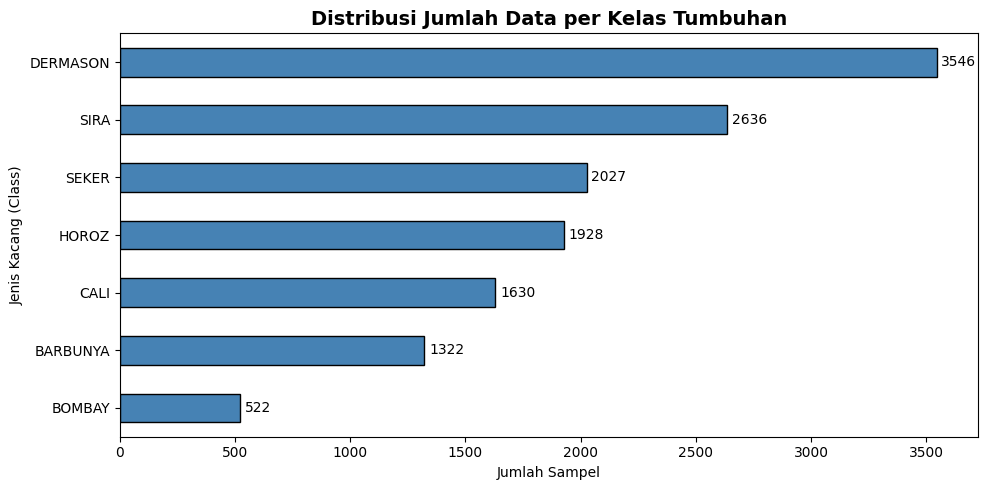


Rasio kelas terbesar vs terkecil: 6.79x
→ DATA TIDAK SEIMBANG. Akan diterapkan SMOTE setelah split.


In [3]:
# ============================================================
# LANGKAH 3: Jumlah kelas dan keseimbangan data
# ============================================================

print("=" * 50)
print("DISTRIBUSI KELAS (LABEL OUTPUT)")
print("=" * 50)

distribusi = df['Class'].value_counts()
print(distribusi)
print(f"\nJumlah kelas : {df['Class'].nunique()} kelas")
print(f"Total sampel : {len(df):,} baris")

# Visualisasi distribusi kelas
plt.figure(figsize=(10, 5))
ax = distribusi.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Distribusi Jumlah Data per Kelas Tumbuhan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Jenis Kacang (Class)')
for i, v in enumerate(distribusi.sort_values()):
    ax.text(v + 20, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

# Cek keseimbangan
min_kelas = distribusi.min()
max_kelas = distribusi.max()
rasio = max_kelas / min_kelas

print(f"\nRasio kelas terbesar vs terkecil: {rasio:.2f}x")
if rasio > 2:
    print("→ DATA TIDAK SEIMBANG. Akan diterapkan SMOTE setelah split.")
else:
    print("→ Data cukup seimbang.")

## 🏷️ Langkah 4 — Identifikasi Tipe Data: Nominal, Ordinal, Kontinu
Setiap fitur diklasifikasikan ke dalam tiga kategori tipe data statistik.

In [4]:
# ============================================================
# LANGKAH 4: Identifikasi tipe data
# ============================================================

tipe_data = {
    'Area'           : ('Kontinu',  'float64', 'Ukuran luas — nilai real tak terbatas'),
    'Perimeter'      : ('Kontinu',  'float64', 'Panjang keliling — nilai real'),
    'MajorAxisLength': ('Kontinu',  'float64', 'Panjang sumbu — nilai real'),
    'MinorAxisLength': ('Kontinu',  'float64', 'Panjang sumbu — nilai real'),
    'AspectRatio'    : ('Kontinu',  'float64', 'Rasio — nilai desimal 0 sampai N'),
    'Eccentricity'   : ('Kontinu',  'float64', 'Nilai 0.0 sampai 1.0 (kontinu)'),
    'ConvexArea'     : ('Kontinu',  'int64',   'Jumlah piksel (diskrit integer)'),
    'EquivDiameter'  : ('Kontinu',  'float64', 'Diameter ekuivalen — nilai real'),
    'Extent'         : ('Kontinu',  'float64', 'Rasio 0.0-1.0 — kontinu'),
    'Solidity'       : ('Kontinu',  'float64', 'Rasio 0.0-1.0 — kontinu'),
    'Roundness'      : ('Kontinu',  'float64', 'Tingkat kebulatan — kontinu'),
    'Compactness'    : ('Kontinu',  'float64', 'Kepadatan — kontinu'),
    'ShapeFactor1'   : ('Kontinu',  'float64', 'Faktor bentuk derivatif — kontinu'),
    'ShapeFactor2'   : ('Kontinu',  'float64', 'Faktor bentuk derivatif — kontinu'),
    'ShapeFactor3'   : ('Kontinu',  'float64', 'Faktor bentuk derivatif — kontinu'),
    'ShapeFactor4'   : ('Kontinu',  'float64', 'Faktor bentuk derivatif — kontinu'),
    'Class'          : ('Nominal',  'object',  'Nama spesies kacang — kategorik tanpa urutan'),
}

print(f"{'Fitur':<20} {'Tipe Statistik':<15} {'Dtype':<10} {'Keterangan'}")
print("-" * 75)
for fitur, (tipe, dtype, ket) in tipe_data.items():
    print(f"{fitur:<20} {tipe:<15} {dtype:<10} {ket}")

print("\nKesimpulan:")
print("- Nominal  : Class (label output, tanpa urutan hierarki)")
print("- Ordinal  : Tidak ada pada dataset ini")
print("- Kontinu  : 16 fitur input (semua berupa nilai real/float)")

Fitur                Tipe Statistik  Dtype      Keterangan
---------------------------------------------------------------------------
Area                 Kontinu         float64    Ukuran luas — nilai real tak terbatas
Perimeter            Kontinu         float64    Panjang keliling — nilai real
MajorAxisLength      Kontinu         float64    Panjang sumbu — nilai real
MinorAxisLength      Kontinu         float64    Panjang sumbu — nilai real
AspectRatio          Kontinu         float64    Rasio — nilai desimal 0 sampai N
Eccentricity         Kontinu         float64    Nilai 0.0 sampai 1.0 (kontinu)
ConvexArea           Kontinu         int64      Jumlah piksel (diskrit integer)
EquivDiameter        Kontinu         float64    Diameter ekuivalen — nilai real
Extent               Kontinu         float64    Rasio 0.0-1.0 — kontinu
Solidity             Kontinu         float64    Rasio 0.0-1.0 — kontinu
Roundness            Kontinu         float64    Tingkat kebulatan — kontinu
Compactness

## 🔎 Langkah 5 — Cek dan Isi Data yang Hilang (Missing Values)
Dicek apakah ada data kosong/null. Jika ada, diisi menggunakan metode imputasi yang sesuai.

In [5]:
# ============================================================
# LANGKAH 5: Cek dan tangani missing values
# ============================================================

print("=" * 55)
print("CEK MISSING VALUES PER KOLOM")
print("=" * 55)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print(missing_df)

total_missing = missing.sum()
print(f"\nTotal missing values: {total_missing}")

if total_missing > 0:
    print("→ Ditemukan missing values. Mengisi dengan median (fitur numerik).")
    from sklearn.impute import SimpleImputer
    fitur_num = df.select_dtypes(include=[np.number]).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    df[fitur_num] = imputer.fit_transform(df[fitur_num])
    print("→ Imputasi selesai. Total missing setelah imputasi:", df.isnull().sum().sum())
else:
    print("→ Tidak ada missing values. Dataset sudah bersih.")

# Cek duplikat
duplikat = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {duplikat}")
if duplikat > 0:
    df = df.drop_duplicates()
    print(f"→ {duplikat} baris duplikat dihapus. Sisa data: {len(df):,} baris")

CEK MISSING VALUES PER KOLOM
                 Jumlah Missing  Persentase (%)
Area                          0             0.0
Perimeter                     0             0.0
MajorAxisLength               0             0.0
MinorAxisLength               0             0.0
AspectRatio                   0             0.0
Eccentricity                  0             0.0
ConvexArea                    0             0.0
EquivDiameter                 0             0.0
Extent                        0             0.0
Solidity                      0             0.0
Roundness                     0             0.0
Compactness                   0             0.0
ShapeFactor1                  0             0.0
ShapeFactor2                  0             0.0
ShapeFactor3                  0             0.0
ShapeFactor4                  0             0.0
Class                         0             0.0

Total missing values: 0
→ Tidak ada missing values. Dataset sudah bersih.

Jumlah baris duplikat: 68
→ 68 

## 🔠 Langkah 6 — Encoding Data Kategorik
Kolom **Class** (output) berupa teks/string perlu diubah menjadi nilai numerik menggunakan **Label Encoding** agar dapat diproses oleh algoritma KNN.

In [6]:
# ============================================================
# LANGKAH 6: Encoding data kategorik
# ============================================================

print("=" * 50)
print("ENCODING KOLOM CLASS (OUTPUT)")
print("=" * 50)

# Label Encoding untuk kolom output (Class)
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])

# Tampilkan mapping encoding
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nMapping Label Encoding:")
print(f"{'Nama Kelas (Original)':<25} {'Kode Numerik (Encoded)'}")
print("-" * 45)
for kelas, kode in mapping.items():
    print(f"{kelas:<25} {kode}")

print(f"\nContoh 5 baris setelah encoding:")
df[['Class', 'Class_encoded']].head()

# Pisahkan X dan y
X = df.drop(columns=['Class', 'Class_encoded'])
y = df['Class_encoded']

print(f"\nShape X (fitur input) : {X.shape}")
print(f"Shape y (label output): {y.shape}")
print(f"\nKeterangan: Semua 16 fitur input sudah numerik (float/int).")
print(f"Tidak ada fitur input kategorik yang perlu di-encode.")

ENCODING KOLOM CLASS (OUTPUT)

Mapping Label Encoding:
Nama Kelas (Original)     Kode Numerik (Encoded)
---------------------------------------------
BARBUNYA                  0
BOMBAY                    1
CALI                      2
DERMASON                  3
HOROZ                     4
SEKER                     5
SIRA                      6

Contoh 5 baris setelah encoding:

Shape X (fitur input) : (13543, 16)
Shape y (label output): (13543,)

Keterangan: Semua 16 fitur input sudah numerik (float/int).
Tidak ada fitur input kategorik yang perlu di-encode.


## 📊 Langkah 7 — Normalisasi Data dan Pairplot
Normalisasi menggunakan **Min-Max Scaler** agar semua fitur memiliki skala yang sama (0 sampai 1), penting untuk KNN yang berbasis jarak. Dilanjutkan dengan visualisasi **pairplot** untuk melihat hubungan antar fitur.

NORMALISASI DATA — MIN-MAX SCALER

SEBELUM Normalisasi (statistik fitur Area dan Perimeter):
            Area  Perimeter  MajorAxisLength  MinorAxisLength
count   13543.00   13543.00         13543.00         13543.00
mean    53048.46     854.99           319.90           202.37
std     29392.44     214.72            85.81            45.05
min     20420.00     524.74           183.60           122.51
25%     36282.50     703.23           253.09           175.89
50%     44580.00     793.90           296.40           192.49
75%     61382.00     977.15           376.31           217.25
max    254616.00    1985.37           738.86           460.20

SESUDAH Normalisasi (Min=0, Max=1):
             Area   Perimeter  MajorAxisLength  MinorAxisLength
count  13543.0000  13543.0000       13543.0000       13543.0000
mean       0.1393      0.2261           0.2455           0.2365
std        0.1255      0.1470           0.1545           0.1334
min        0.0000      0.0000           0.0000          

<Figure size 200x200 with 0 Axes>

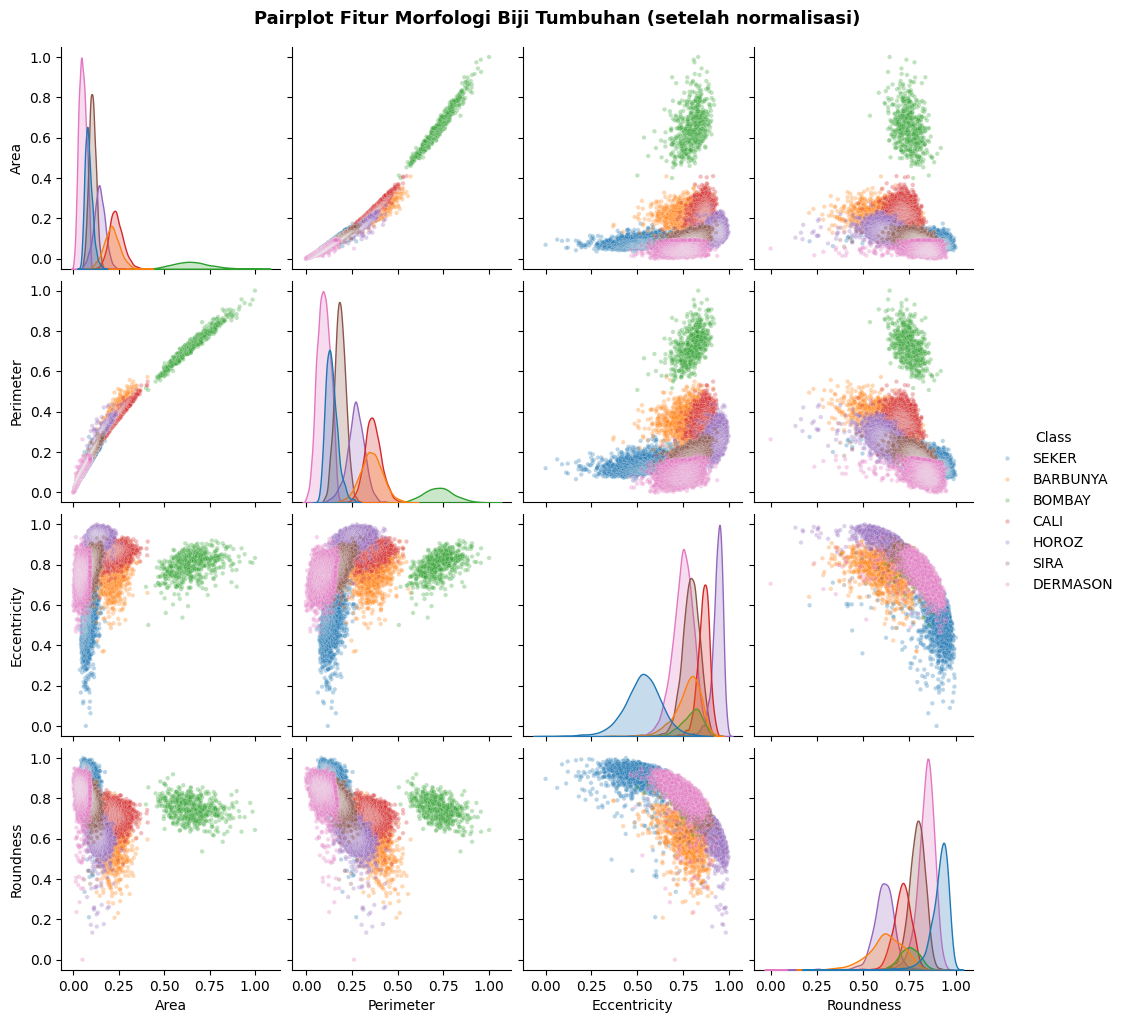


Interpretasi Pairplot:
- Diagonal  : Distribusi KDE masing-masing fitur per kelas
- Off-diag  : Scatter plot hubungan dua fitur (warna = kelas)
- Area & Perimeter : Berkorelasi kuat (distribusi overlap antar kelas)
- Roundness & Eccentricity : Pemisah kelas yang lebih baik


In [7]:
# ============================================================
# LANGKAH 7: Normalisasi data + Pairplot
# ============================================================

print("=" * 55)
print("NORMALISASI DATA — MIN-MAX SCALER")
print("=" * 55)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nSEBELUM Normalisasi (statistik fitur Area dan Perimeter):")
print(X[['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength']].describe().round(2))

print("\nSESUDAH Normalisasi (Min=0, Max=1):")
print(X_scaled_df[['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength']].describe().round(4))

# ---- PAIRPLOT (4 fitur utama agar tidak terlalu berat) ----
print("\nMembuat pairplot 4 fitur utama...")
df_plot = X_scaled_df[['Area', 'Perimeter', 'Eccentricity', 'Roundness']].copy()
df_plot['Class'] = df['Class'].values

plt.figure(figsize=(2, 2))
g = sns.pairplot(df_plot, hue='Class', plot_kws={'alpha': 0.3, 's': 10},
                 diag_kind='kde', corner=False)
g.fig.suptitle('Pairplot Fitur Morfologi Biji Tumbuhan (setelah normalisasi)',
               y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pairplot_tumbuhan.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nInterpretasi Pairplot:")
print("- Diagonal  : Distribusi KDE masing-masing fitur per kelas")
print("- Off-diag  : Scatter plot hubungan dua fitur (warna = kelas)")
print("- Area & Perimeter : Berkorelasi kuat (distribusi overlap antar kelas)")
print("- Roundness & Eccentricity : Pemisah kelas yang lebih baik")

## ✂️ Langkah 8 — Split Dataset dan Penerapan SMOTE
Dataset dibagi dengan rasio **80:20** (training:testing) menggunakan stratified split untuk menjaga proporsi kelas. Kemudian diterapkan **SMOTE** pada data training untuk menyeimbangkan kelas.

In [8]:
# ============================================================
# LANGKAH 8: Split dataset 80:20 + SMOTE
# ============================================================

print("=" * 55)
print("SPLIT DATASET — RASIO 80:20")
print("=" * 55)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data training : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Data testing  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

print("\nDistribusi kelas pada data TRAINING (sebelum SMOTE):")
for k, v in sorted(Counter(y_train).items()):
    print(f"  Kelas {k} ({le.classes_[k]}): {v} sampel")

# Terapkan SMOTE untuk menyeimbangkan kelas pada training
print("\nMenerapkan SMOTE untuk menyeimbangkan kelas...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nSetelah SMOTE:")
print(f"Jumlah data training: {len(X_train_sm):,} baris")
print("\nDistribusi kelas pada data TRAINING (sesudah SMOTE):")
for k, v in sorted(Counter(y_train_sm).items()):
    print(f"  Kelas {k} ({le.classes_[k]}): {v} sampel")

SPLIT DATASET — RASIO 80:20
Data training : 10,834 baris (80.0%)
Data testing  : 2,709 baris (20.0%)

Distribusi kelas pada data TRAINING (sebelum SMOTE):
  Kelas 0 (BARBUNYA): 1057 sampel
  Kelas 1 (BOMBAY): 418 sampel
  Kelas 2 (CALI): 1304 sampel
  Kelas 3 (DERMASON): 2837 sampel
  Kelas 4 (HOROZ): 1488 sampel
  Kelas 5 (SEKER): 1621 sampel
  Kelas 6 (SIRA): 2109 sampel

Menerapkan SMOTE untuk menyeimbangkan kelas...

Setelah SMOTE:
Jumlah data training: 19,859 baris

Distribusi kelas pada data TRAINING (sesudah SMOTE):
  Kelas 0 (BARBUNYA): 2837 sampel
  Kelas 1 (BOMBAY): 2837 sampel
  Kelas 2 (CALI): 2837 sampel
  Kelas 3 (DERMASON): 2837 sampel
  Kelas 4 (HOROZ): 2837 sampel
  Kelas 5 (SEKER): 2837 sampel
  Kelas 6 (SIRA): 2837 sampel


## 🤖 Langkah 9 — Algoritma KNN dan Pencarian K-Optimal
Menggunakan **K-Nearest Neighbour (KNN)** untuk klasifikasi. Nilai K-optimal dicari dengan menguji berbagai nilai K dan memilih yang menghasilkan akurasi tertinggi pada data validasi.

PENCARIAN NILAI K-OPTIMAL (K=1 sampai K=20)
  K= 1 → Akurasi: 89.70%
  K= 2 → Akurasi: 89.41%
  K= 3 → Akurasi: 90.48%
  K= 4 → Akurasi: 90.25%
  K= 5 → Akurasi: 90.62%
  K= 6 → Akurasi: 90.96%
  K= 7 → Akurasi: 91.21%
  K= 8 → Akurasi: 91.03%
  K= 9 → Akurasi: 91.07%
  K=10 → Akurasi: 91.18%
  K=11 → Akurasi: 91.33%
  K=12 → Akurasi: 91.55%
  K=13 → Akurasi: 91.69%
  K=14 → Akurasi: 91.51%
  K=15 → Akurasi: 91.40%
  K=16 → Akurasi: 91.25%
  K=17 → Akurasi: 91.10%
  K=18 → Akurasi: 91.25%
  K=19 → Akurasi: 91.21%
  K=20 → Akurasi: 91.29%

★ K-OPTIMAL: K = 13 dengan akurasi = 91.69%


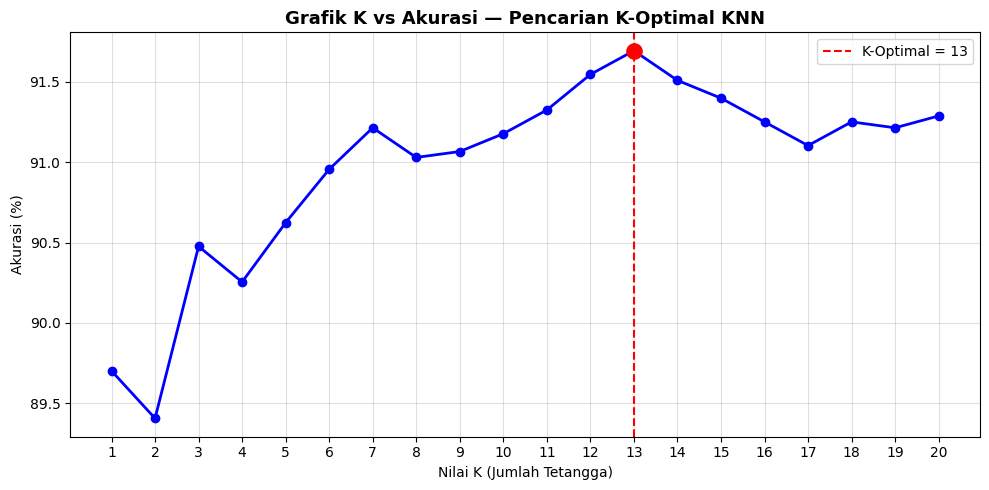


Model final dilatih dengan K=13. Siap dievaluasi.


In [9]:
# ============================================================
# LANGKAH 9: KNN dan pencarian K-optimal
# ============================================================

print("=" * 55)
print("PENCARIAN NILAI K-OPTIMAL (K=1 sampai K=20)")
print("=" * 55)

akurasi_k = []
K_range = range(1, 21)

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_sm, y_train_sm)
    acc = accuracy_score(y_test, knn.predict(X_test))
    akurasi_k.append(acc)
    print(f"  K={k:2d} → Akurasi: {acc*100:.2f}%")

# K-optimal = K dengan akurasi tertinggi
k_optimal = K_range[np.argmax(akurasi_k)]
akurasi_optimal = max(akurasi_k)

print(f"\n★ K-OPTIMAL: K = {k_optimal} dengan akurasi = {akurasi_optimal*100:.2f}%")

# Grafik K vs Akurasi
plt.figure(figsize=(10, 5))
plt.plot(list(K_range), [a*100 for a in akurasi_k], 'bo-', linewidth=2, markersize=6)
plt.axvline(x=k_optimal, color='red', linestyle='--', label=f'K-Optimal = {k_optimal}')
plt.scatter([k_optimal], [akurasi_optimal*100], color='red', s=120, zorder=5)
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Akurasi (%)')
plt.title('Grafik K vs Akurasi — Pencarian K-Optimal KNN', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.xticks(list(K_range))
plt.tight_layout()
plt.savefig('k_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

# Training model final dengan K-optimal
knn_final = KNeighborsClassifier(n_neighbors=k_optimal, metric='euclidean')
knn_final.fit(X_train_sm, y_train_sm)
y_pred = knn_final.predict(X_test)
print(f"\nModel final dilatih dengan K={k_optimal}. Siap dievaluasi.")

## 📉 Langkah 10 — Confusion Matrix pada Data Testing
Confusion matrix menampilkan prediksi yang benar dan salah untuk setiap kelas, sehingga dapat diketahui pola kesalahan model pada data testing.

CONFUSION MATRIX — DATA TESTING

Confusion Matrix (baris=aktual, kolom=prediksi):
          BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
BARBUNYA       241       0    13         0      1      4     6
BOMBAY           0     104     0         0      0      0     0
CALI             9       0   309         0      4      2     2
DERMASON         0       0     0       630      0     18    61
HOROZ            1       0    13         2    348      0     8
SEKER            3       0     1         5      0    384    13
SIRA             4       0     1        35      7     12   468


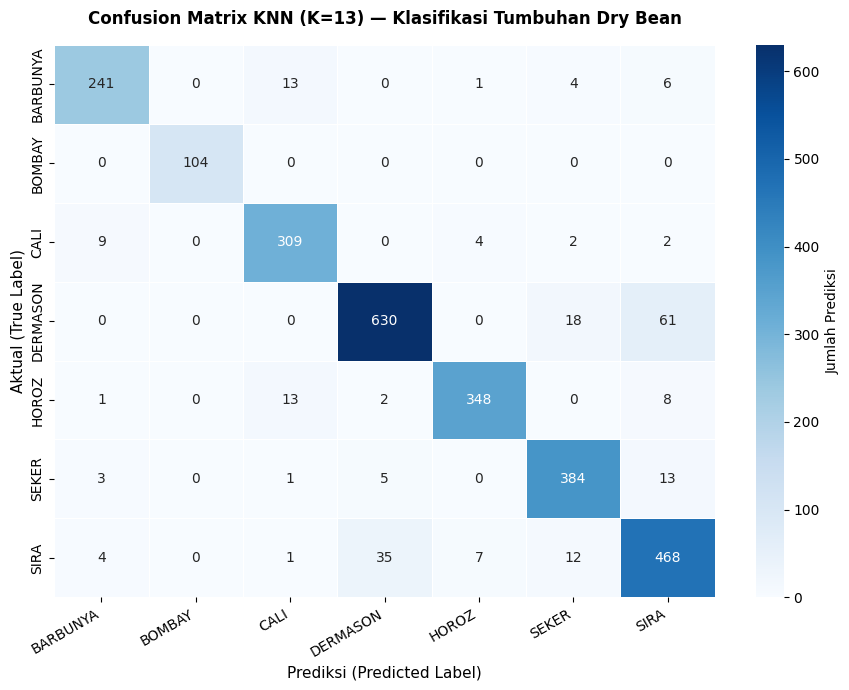


Penjelasan Confusion Matrix:
- Diagonal utama (warna gelap) : Prediksi BENAR (True Positive per kelas)
- Di luar diagonal             : Prediksi SALAH (misklasifikasi)
- Angka besar di diagonal      : Model berhasil mengenali kelas tersebut
- Angka kecil di luar diagonal : Tingkat kesalahan rendah antar kelas


In [10]:
# ============================================================
# LANGKAH 10: Confusion Matrix
# ============================================================

print("=" * 55)
print("CONFUSION MATRIX — DATA TESTING")
print("=" * 55)

cm = confusion_matrix(y_test, y_pred)
label_kelas = le.classes_

# Tampilkan sebagai tabel
cm_df = pd.DataFrame(cm, index=label_kelas, columns=label_kelas)
print("\nConfusion Matrix (baris=aktual, kolom=prediksi):")
print(cm_df)

# Heatmap Confusion Matrix
plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Jumlah Prediksi'})
plt.title(f'Confusion Matrix KNN (K={k_optimal}) — Klasifikasi Tumbuhan Dry Bean',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Prediksi (Predicted Label)', fontsize=11)
plt.ylabel('Aktual (True Label)', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPenjelasan Confusion Matrix:")
print("- Diagonal utama (warna gelap) : Prediksi BENAR (True Positive per kelas)")
print("- Di luar diagonal             : Prediksi SALAH (misklasifikasi)")
print("- Angka besar di diagonal      : Model berhasil mengenali kelas tersebut")
print("- Angka kecil di luar diagonal : Tingkat kesalahan rendah antar kelas")

## 📈 Langkah 11 — Evaluasi Model: Akurasi, Presisi, Recall, F1-Score
Evaluasi model menggunakan **Classification Report** yang mencakup empat metrik utama untuk setiap kelas.

EVALUASI MODEL KNN — CLASSIFICATION REPORT

Akurasi Keseluruhan (Overall Accuracy): 91.69%

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.94      0.89      0.91       709
       HOROZ       0.97      0.94      0.95       372
       SEKER       0.91      0.95      0.93       406
        SIRA       0.84      0.89      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


Ringkasan Metrik per Kelas (%):
   Kelas  Presisi  Recall  F1-Score
BARBUNYA    93.41   90.94     92.16
  BOMBAY   100.00  100.00    100.00
    CALI    91.69   94.79     93.21
DERMASON    93.75   88.86     91.24
   HOROZ    96.67   93.55     95.08
   SEKER    91.43   94.58     92.98
   

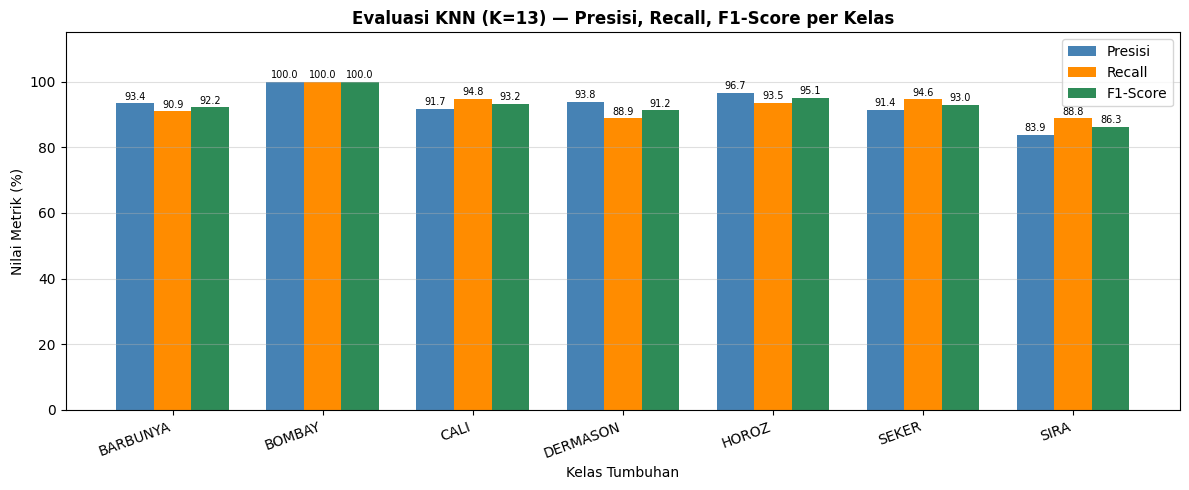


Penjelasan Metrik:
- Akurasi  : Proporsi prediksi benar dari total seluruh prediksi
- Presisi  : Dari semua prediksi positif, berapa yang benar (TP / TP+FP)
- Recall   : Dari semua data positif aktual, berapa yang terdeteksi (TP / TP+FN)
- F1-Score : Rata-rata harmonik Presisi dan Recall — ukuran keseimbangan


In [11]:
# ============================================================
# LANGKAH 11: Evaluasi model — akurasi, presisi, recall, F1
# ============================================================

print("=" * 65)
print("EVALUASI MODEL KNN — CLASSIFICATION REPORT")
print("=" * 65)

# Hitung akurasi keseluruhan
akurasi = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Keseluruhan (Overall Accuracy): {akurasi*100:.2f}%")

# Classification report lengkap
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_kelas))

# Tampilkan metrik per kelas dalam bentuk DataFrame
from sklearn.metrics import precision_score, recall_score, f1_score

presisi  = precision_score(y_test, y_pred, average=None)
recall   = recall_score(y_test, y_pred, average=None)
f1       = f1_score(y_test, y_pred, average=None)

eval_df = pd.DataFrame({
    'Kelas'    : label_kelas,
    'Presisi'  : (presisi * 100).round(2),
    'Recall'   : (recall  * 100).round(2),
    'F1-Score' : (f1      * 100).round(2)
})
print("\nRingkasan Metrik per Kelas (%):")
print(eval_df.to_string(index=False))

# Visualisasi metrik
x = np.arange(len(label_kelas))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, presisi*100,  width, label='Presisi',  color='steelblue')
ax.bar(x,         recall*100,   width, label='Recall',   color='darkorange')
ax.bar(x + width, f1*100,       width, label='F1-Score', color='seagreen')

ax.set_xlabel('Kelas Tumbuhan')
ax.set_ylabel('Nilai Metrik (%)')
ax.set_title(f'Evaluasi KNN (K={k_optimal}) — Presisi, Recall, F1-Score per Kelas',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_kelas, rotation=20, ha='right')
ax.legend()
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.4)

# Tambahkan label akurasi di atas bar
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('evaluasi_metrik.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPenjelasan Metrik:")
print("- Akurasi  : Proporsi prediksi benar dari total seluruh prediksi")
print("- Presisi  : Dari semua prediksi positif, berapa yang benar (TP / TP+FP)")
print("- Recall   : Dari semua data positif aktual, berapa yang terdeteksi (TP / TP+FN)")
print("- F1-Score : Rata-rata harmonik Presisi dan Recall — ukuran keseimbangan")